<a href="https://colab.research.google.com/github/kimjehui/DL300/blob/main/%5B%EC%8B%A4%EC%8A%B5_PyTorch%5DPart1_Ch02_%EB%A9%80%ED%8B%B0%EB%AA%A8%EB%8D%B8_%EB%B6%84%EB%A5%98_%EC%9D%B8%EB%AC%BC_%EC%82%AC%EC%A7%84%EC%97%90%EC%84%9C_%EC%84%B1%EB%B3%84%EA%B3%BC_%ED%91%9C%EC%A0%95_%EB%B6%84%EC%84%9D%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1. Ch02. 멀티모델 분류 - 인물 사진에서 성별과 표정 분석하기 (PyTorch 버전)

## CelebA 데이터셋 소개
- 202,599장의 유명인 얼굴 이미지
- 40가지 이진 속성 레이블 포함 (성별, 표정 등)
- 이 실습에서는 **성별(Male)** 과 **표정(Smiling)** 두 가지 속성을 분류합니다

## 학습 목표
1. **단순 분리 모델**: 성별 모델, 표정 모델을 각각 별도로 학습
2. **멀티 출력 모델**: 하나의 CNN으로 성별과 표정을 동시에 예측
3. PyTorch의 `nn.Module`을 사용한 모델 정의 및 학습

## Step 1. 라이브러리 임포트

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

print(f'PyTorch version: {torch.__version__}')
print(f'GPU 사용 가능: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

PyTorch version: 2.10.0+cu128
GPU 사용 가능: True
사용 디바이스: cuda


## Step 2. 데이터 다운로드 및 로드

CelebA 소용량 버전(celeba_small.npz)을 다운로드합니다.

In [2]:
import os
import numpy as np

filename = 'celeba_small.npz'

# ── 방법 1: requests로 브라우저 헤더 위장 ──────────────────────
def try_download_requests(url, path):
    try:
        import requests
        headers = {
            'User-Agent': (
                'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                'AppleWebKit/537.36 (KHTML, like Gecko) '
                'Chrome/120.0.0.0 Safari/537.36'
            )
        }
        r = requests.get(url, headers=headers, timeout=60)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
            return True
        print(f'requests 실패: HTTP {r.status_code}')
    except Exception as e:
        print(f'requests 오류: {e}')
    return False

# ── 방법 2: tensorflow_datasets로 CelebA 로드 후 npz 생성 ──────
def build_npz_from_tfds(path, n_samples=10000, img_size=(72, 59)):
    """tfds에서 CelebA를 로드해 celeba_small.npz 포맷으로 저장"""
    print('tensorflow_datasets로 CelebA 로드 중 (처음 실행 시 시간이 걸립니다)...')
    import tensorflow_datasets as tfds
    import tensorflow as tf

    # CelebA 속성 이름 40개 (알파벳순)
    ATTR_NAMES = [
        '5_o_Clock_Shadow','Arched_Eyebrows','Attractive','Bags_Under_Eyes',
        'Bald','Bangs','Big_Lips','Big_Nose','Black_Hair','Blond_Hair',
        'Blurry','Brown_Hair','Bushy_Eyebrows','Chubby','Double_Chin',
        'Eyeglasses','Goatee','Gray_Hair','Heavy_Makeup','High_Cheekbones',
        'Male','Mouth_Slightly_Open','Mustache','Narrow_Eyes','No_Beard',
        'Oval_Face','Pale_Skin','Pointy_Nose','Receding_Hairline',
        'Rosy_Cheeks','Sideburns','Smiling','Straight_Hair','Wavy_Hair',
        'Wearing_Earrings','Wearing_Hat','Wearing_Lipstick',
        'Wearing_Necklace','Wearing_Necktie','Young'
    ]

    ds = tfds.load('celeb_a', split='train', as_supervised=False)
    ds = ds.take(n_samples).batch(256).prefetch(1)

    images_list, labels_list = [], []
    for batch in ds:
        imgs = batch['image'].numpy()                   # (B, H, W, 3)
        # 리사이즈
        imgs_resized = np.array([
            np.array(tf.image.resize(img, img_size)) for img in imgs
        ], dtype=np.uint8)
        images_list.append(imgs_resized)

        # 속성 추출 (0/1 → -1/1)
        attrs = np.stack(
            [batch['attributes'][k].numpy().astype(np.int8) for k in ATTR_NAMES],
            axis=1
        )
        attrs = attrs * 2 - 1   # 0→-1, 1→1
        labels_list.append(attrs)

    images_all = np.concatenate(images_list, axis=0)
    labels_all  = np.concatenate(labels_list, axis=0)
    label_names = np.array(ATTR_NAMES)

    np.savez_compressed(path, images=images_all,
                        labels=labels_all, label_names=label_names)
    print(f'npz 저장 완료: {path}  (이미지 {len(images_all)}장)')

# ── 실행 흐름 ─────────────────────────────────────────────────
if os.path.exists(filename):
    print('이미 다운로드된 파일이 있습니다.')
else:
    URL = 'https://storage.googleapis.com/download.tensorflow.org/data/celeba_small.npz'
    print('방법 1: requests로 다운로드 시도...')
    ok = try_download_requests(URL, filename)
    if not ok:
        print('방법 2: tensorflow_datasets로 생성...')
        build_npz_from_tfds(filename)

print('완료! 파일 크기:', os.path.getsize(filename) // 1024, 'KB')


방법 1: requests로 다운로드 시도...
requests 실패: HTTP 403
방법 2: tensorflow_datasets로 생성...
tensorflow_datasets로 CelebA 로드 중 (처음 실행 시 시간이 걸립니다)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.6VX3FB_2.1.0/celeb_a-validation.tfrecord*...:   0%|    …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.6VX3FB_2.1.0/celeb_a-test.tfrecord*...:   0%|          …

Dataset celeb_a downloaded and prepared to /root/tensorflow_datasets/celeb_a/2.1.0. Subsequent calls will reuse this data.
npz 저장 완료: celeba_small.npz  (이미지 10000장)
완료! 파일 크기: 102508 KB


In [3]:
# npz 파일 로드
data = np.load('celeba_small.npz')
print('데이터셋 키:', list(data.keys()))

데이터셋 키: ['images', 'labels', 'label_names']


In [4]:
# 데이터 확인
images = data['images']       # (N, H, W, C)
labels = data['labels']       # (N, 40) - 40개 속성
label_names = data['label_names']  # 속성 이름 배열

print(f'이미지 shape: {images.shape}')
print(f'레이블 shape: {labels.shape}')
print(f'레이블 종류: {label_names}')
print(f'이미지 dtype: {images.dtype}')
print(f'이미지 값 범위: [{images.min()}, {images.max()}]')

이미지 shape: (10000, 72, 59, 3)
레이블 shape: (10000, 40)
레이블 종류: ['5_o_Clock_Shadow' 'Arched_Eyebrows' 'Attractive' 'Bags_Under_Eyes'
 'Bald' 'Bangs' 'Big_Lips' 'Big_Nose' 'Black_Hair' 'Blond_Hair' 'Blurry'
 'Brown_Hair' 'Bushy_Eyebrows' 'Chubby' 'Double_Chin' 'Eyeglasses'
 'Goatee' 'Gray_Hair' 'Heavy_Makeup' 'High_Cheekbones' 'Male'
 'Mouth_Slightly_Open' 'Mustache' 'Narrow_Eyes' 'No_Beard' 'Oval_Face'
 'Pale_Skin' 'Pointy_Nose' 'Receding_Hairline' 'Rosy_Cheeks' 'Sideburns'
 'Smiling' 'Straight_Hair' 'Wavy_Hair' 'Wearing_Earrings' 'Wearing_Hat'
 'Wearing_Lipstick' 'Wearing_Necklace' 'Wearing_Necktie' 'Young']
이미지 dtype: uint8
이미지 값 범위: [0, 255]


## Step 3. 데이터 전처리

- **성별(Male)**: 레이블 인덱스 20
- **표정(Smiling)**: 레이블 인덱스 31

In [5]:
# 레이블 인덱스 확인
label_names_list = list(label_names)
male_idx = label_names_list.index('Male')
smile_idx = label_names_list.index('Smiling')
print(f'Male 인덱스: {male_idx}')
print(f'Smiling 인덱스: {smile_idx}')

Male 인덱스: 20
Smiling 인덱스: 31


In [6]:
# 이미지 정규화 (0~255 → 0~1)
images_norm = images.astype(np.float32) / 255.0

# 성별 레이블 추출 (-1/1 → 0/1로 변환)
gender_labels = labels[:, male_idx]         # -1 or 1
gender_labels = ((gender_labels + 1) // 2).astype(np.int64)  # 0 or 1

# 표정 레이블 추출
smile_labels = labels[:, smile_idx]
smile_labels = ((smile_labels + 1) // 2).astype(np.int64)

print(f'이미지 shape: {images_norm.shape}')
print(f'성별 레이블 shape: {gender_labels.shape}, 예시: {gender_labels[:5]}')
print(f'표정 레이블 shape: {smile_labels.shape}, 예시: {smile_labels[:5]}')
print(f'성별 분포 - 여성(0): {(gender_labels==0).sum()}, 남성(1): {(gender_labels==1).sum()}')
print(f'표정 분포 - 무표정(0): {(smile_labels==0).sum()}, 미소(1): {(smile_labels==1).sum()}')

이미지 shape: (10000, 72, 59, 3)
성별 레이블 shape: (10000,), 예시: [0 1 0 0 1]
표정 레이블 shape: (10000,), 예시: [1 1 1 1 0]
성별 분포 - 여성(0): 5810, 남성(1): 4190
표정 분포 - 무표정(0): 5190, 미소(1): 4810


In [7]:
# PyTorch: (N, H, W, C) → (N, C, H, W)
images_tensor = torch.tensor(images_norm).permute(0, 3, 1, 2)  # (N, 3, H, W)
gender_tensor = torch.tensor(gender_labels)
smile_tensor = torch.tensor(smile_labels)

print(f'이미지 텐서 shape: {images_tensor.shape}')
print(f'성별 텐서 shape: {gender_tensor.shape}')
print(f'표정 텐서 shape: {smile_tensor.shape}')

이미지 텐서 shape: torch.Size([10000, 3, 72, 59])
성별 텐서 shape: torch.Size([10000])
표정 텐서 shape: torch.Size([10000])


## Step 4. 데이터셋 및 DataLoader 구성

In [8]:
class CelebADataset(Dataset):
    """CelebA 커스텀 데이터셋"""
    def __init__(self, images, gender_labels, smile_labels):
        self.images = images
        self.gender = gender_labels
        self.smile = smile_labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.gender[idx], self.smile[idx]


# 전체 데이터셋 생성
full_dataset = CelebADataset(images_tensor, gender_tensor, smile_tensor)

# 학습/검증/테스트 분할 (70% / 15% / 15%)
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f'학습: {len(train_dataset)}, 검증: {len(val_dataset)}, 테스트: {len(test_dataset)}')

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

학습: 7000, 검증: 1500, 테스트: 1500


## Step 5. 데이터 시각화

/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/936008335.py:14: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

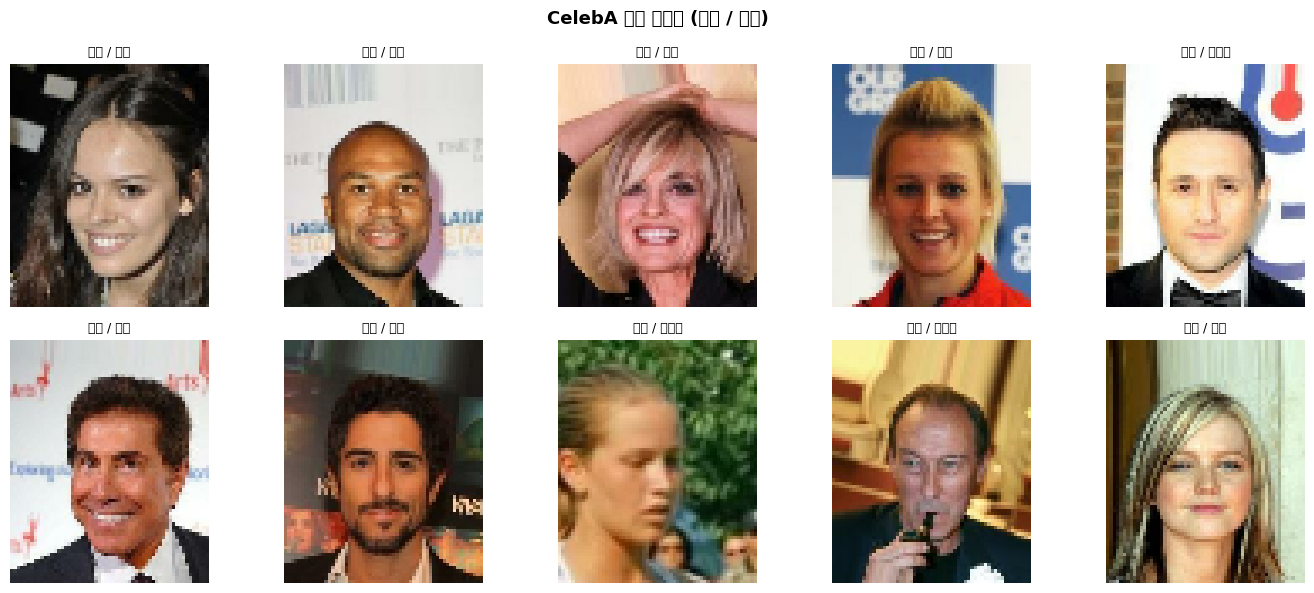

In [9]:
# 샘플 이미지 시각화
gender_map = {0: '여성', 1: '남성'}
smile_map  = {0: '무표정', 1: '미소'}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = images_norm[i]  # (H, W, C)
    ax.imshow(img)
    g = gender_labels[i]
    s = smile_labels[i]
    ax.set_title(f'{gender_map[g]} / {smile_map[s]}', fontsize=9)
    ax.axis('off')
plt.suptitle('CelebA 샘플 이미지 (성별 / 표정)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1750775064.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_lay

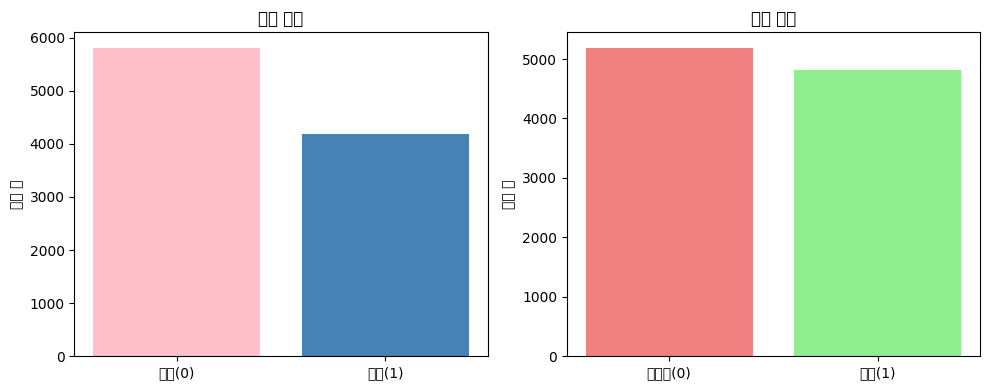

In [10]:
# 레이블 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

gender_counts = pd.Series(gender_labels).value_counts().sort_index()
axes[0].bar(['여성(0)', '남성(1)'], gender_counts.values, color=['pink', 'steelblue'])
axes[0].set_title('성별 분포')
axes[0].set_ylabel('샘플 수')

smile_counts = pd.Series(smile_labels).value_counts().sort_index()
axes[1].bar(['무표정(0)', '미소(1)'], smile_counts.values, color=['lightcoral', 'lightgreen'])
axes[1].set_title('표정 분포')
axes[1].set_ylabel('샘플 수')

plt.tight_layout()
plt.show()

---
## Model 1. 단순 분리 모델 (성별 모델 / 표정 모델 각각 학습)

동일한 CNN 구조를 사용하되, 두 모델을 **독립적으로** 학습합니다.

In [11]:
class SimpleModel(nn.Module):
    """
    단순 이진 분류 CNN
    Input:  (batch, 3, 72, 59)
    Output: (batch, 2)  - 이진 분류 로짓
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),   # → (32, 70, 57)
            nn.ReLU(),
            nn.MaxPool2d(2),                    # → (32, 35, 28)

            nn.Conv2d(32, 64, kernel_size=3),   # → (64, 33, 26)
            nn.ReLU(),
            nn.MaxPool2d(2),                    # → (64, 16, 13)

            nn.Conv2d(64, 64, kernel_size=3),   # → (64, 14, 11)
            nn.ReLU(),
            nn.MaxPool2d(2),                    # → (64,  7,  5)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 5, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# 모델 구조 확인
sample = torch.zeros(1, 3, 72, 59)
m = SimpleModel()
out = m(sample)
print(f'출력 shape: {out.shape}')  # (1, 2)
print(m)

출력 shape: torch.Size([1, 2])
SimpleModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2240, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


### 학습 헬퍼 함수 정의

In [12]:
def train_simple_model(model, train_loader, val_loader, target='gender', epochs=15, lr=1e-3):
    """
    단일 출력 모델 학습 함수
    target: 'gender' 또는 'smile'
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- 학습 단계 ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for imgs, gender, smile in train_loader:
            imgs = imgs.to(device)
            labels = gender.to(device) if target == 'gender' else smile.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += imgs.size(0)

        # --- 검증 단계 ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, gender, smile in val_loader:
                imgs = imgs.to(device)
                labels = gender.to(device) if target == 'gender' else smile.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += imgs.size(0)

        # 에포크별 기록
        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc  = train_correct / train_total
        v_acc  = val_correct / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f'Epoch [{epoch+1:2d}/{epochs}]  '
              f'loss: {t_loss:.4f}  acc: {t_acc:.4f}  '
              f'val_loss: {v_loss:.4f}  val_acc: {v_acc:.4f}')

    return history


def plot_history(history, title='Training History'):
    """학습 곡선 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'],   label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 성별 모델 학습

In [13]:
gender_model = SimpleModel()
print('=== 성별 모델 학습 ===')
gender_history = train_simple_model(gender_model, train_loader, val_loader, target='gender', epochs=15)

=== 성별 모델 학습 ===
Epoch [ 1/15]  loss: 0.5666  acc: 0.6966  val_loss: 0.4834  val_acc: 0.7707
Epoch [ 2/15]  loss: 0.3194  acc: 0.8597  val_loss: 0.2477  val_acc: 0.8973
Epoch [ 3/15]  loss: 0.2076  acc: 0.9164  val_loss: 0.2282  val_acc: 0.9040
Epoch [ 4/15]  loss: 0.1628  acc: 0.9371  val_loss: 0.1966  val_acc: 0.9273
Epoch [ 5/15]  loss: 0.1426  acc: 0.9461  val_loss: 0.1701  val_acc: 0.9287
Epoch [ 6/15]  loss: 0.1230  acc: 0.9524  val_loss: 0.1685  val_acc: 0.9327
Epoch [ 7/15]  loss: 0.1111  acc: 0.9569  val_loss: 0.1752  val_acc: 0.9347
Epoch [ 8/15]  loss: 0.0930  acc: 0.9650  val_loss: 0.1819  val_acc: 0.9313
Epoch [ 9/15]  loss: 0.0803  acc: 0.9671  val_loss: 0.1832  val_acc: 0.9407
Epoch [10/15]  loss: 0.0672  acc: 0.9741  val_loss: 0.1764  val_acc: 0.9380
Epoch [11/15]  loss: 0.0575  acc: 0.9787  val_loss: 0.1999  val_acc: 0.9420
Epoch [12/15]  loss: 0.0510  acc: 0.9786  val_loss: 0.2482  val_acc: 0.9333
Epoch [13/15]  loss: 0.0395  acc: 0.9850  val_loss: 0.2063  val_acc: 0.

/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


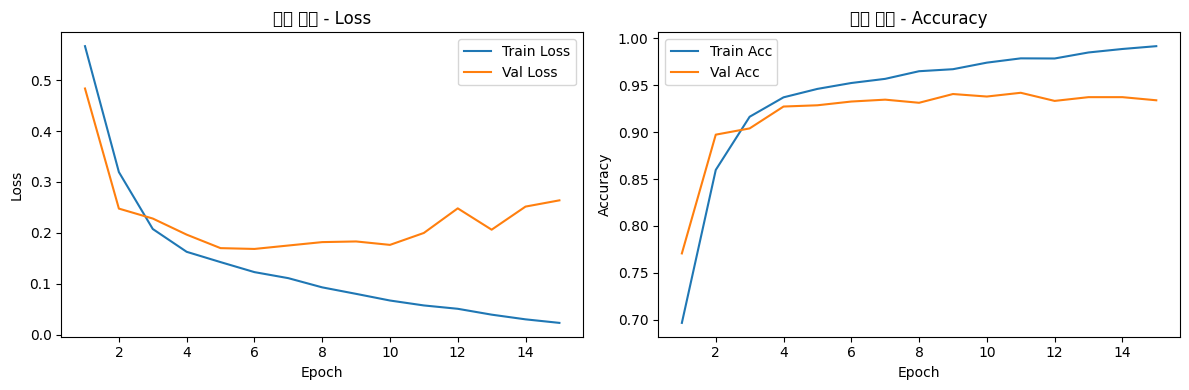

In [14]:
plot_history(gender_history, title='성별 모델')

### 표정 모델 학습

In [15]:
smile_model = SimpleModel()
print('=== 표정 모델 학습 ===')
smile_history = train_simple_model(smile_model, train_loader, val_loader, target='smile', epochs=15)

=== 표정 모델 학습 ===
Epoch [ 1/15]  loss: 0.6351  acc: 0.6241  val_loss: 0.4734  val_acc: 0.7707
Epoch [ 2/15]  loss: 0.3864  acc: 0.8326  val_loss: 0.3262  val_acc: 0.8600
Epoch [ 3/15]  loss: 0.2859  acc: 0.8780  val_loss: 0.2938  val_acc: 0.8747
Epoch [ 4/15]  loss: 0.2533  acc: 0.8926  val_loss: 0.2795  val_acc: 0.8780
Epoch [ 5/15]  loss: 0.2319  acc: 0.9046  val_loss: 0.2476  val_acc: 0.8933
Epoch [ 6/15]  loss: 0.2145  acc: 0.9094  val_loss: 0.2477  val_acc: 0.9007
Epoch [ 7/15]  loss: 0.2018  acc: 0.9137  val_loss: 0.2580  val_acc: 0.8913
Epoch [ 8/15]  loss: 0.1796  acc: 0.9266  val_loss: 0.2635  val_acc: 0.8940
Epoch [ 9/15]  loss: 0.1718  acc: 0.9289  val_loss: 0.2471  val_acc: 0.8993
Epoch [10/15]  loss: 0.1602  acc: 0.9343  val_loss: 0.2660  val_acc: 0.8927
Epoch [11/15]  loss: 0.1433  acc: 0.9419  val_loss: 0.2756  val_acc: 0.8887
Epoch [12/15]  loss: 0.1279  acc: 0.9491  val_loss: 0.2797  val_acc: 0.8927
Epoch [13/15]  loss: 0.1248  acc: 0.9489  val_loss: 0.3282  val_acc: 0.

/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/806687330.py:87: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


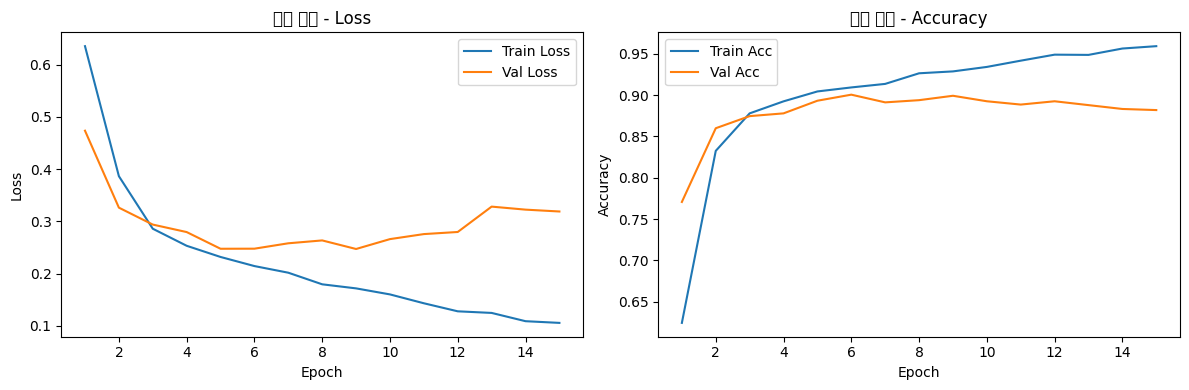

In [16]:
plot_history(smile_history, title='표정 모델')

### 단순 모델 예측 시각화

/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/1015420174.py:38: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layo

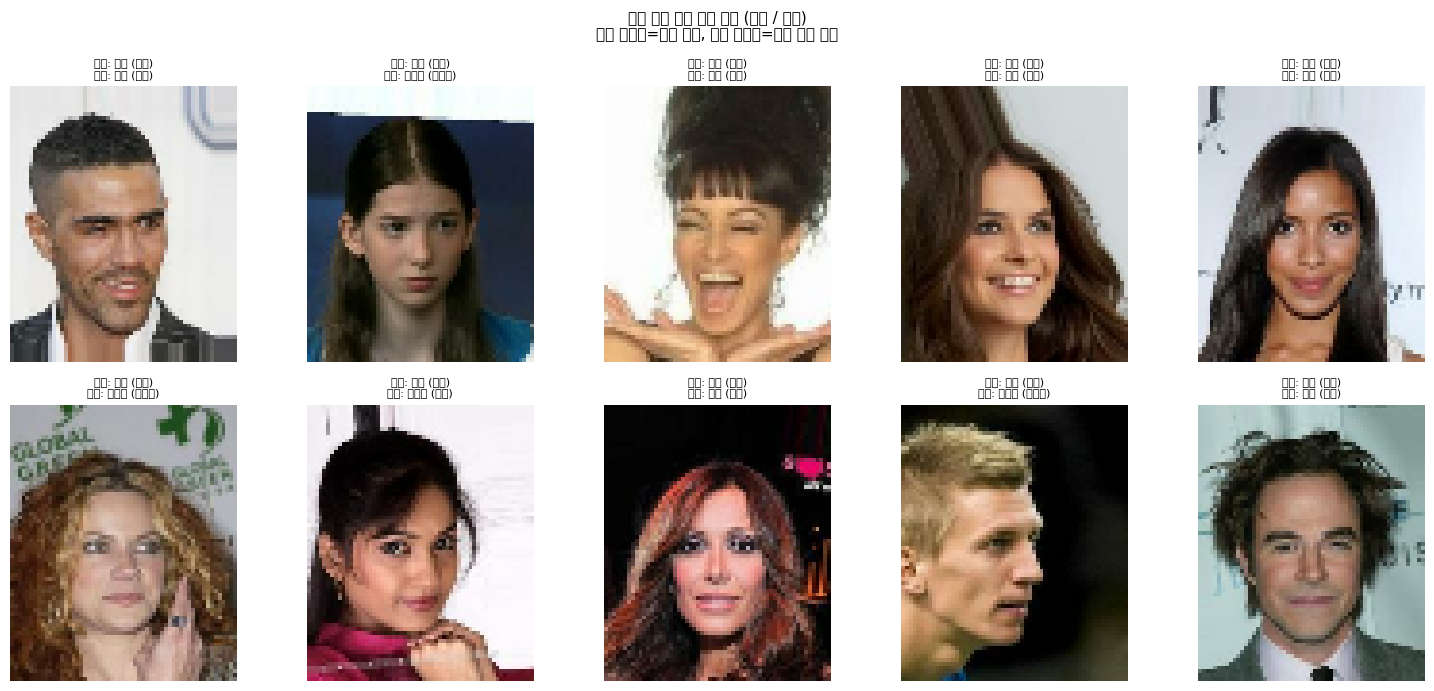

In [17]:
gender_model.eval()
smile_model.eval()

# 테스트셋에서 샘플 가져오기
sample_imgs, sample_gender, sample_smile = next(iter(test_loader))
sample_imgs_dev = sample_imgs.to(device)

with torch.no_grad():
    gender_preds = gender_model(sample_imgs_dev).argmax(dim=1).cpu()
    smile_preds  = smile_model(sample_imgs_dev).argmax(dim=1).cpu()

# 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    ax.imshow(img)

    g_true = gender_map[sample_gender[i].item()]
    g_pred = gender_map[gender_preds[i].item()]
    s_true = smile_map[sample_smile[i].item()]
    s_pred = smile_map[smile_preds[i].item()]

    g_color = 'green' if sample_gender[i] == gender_preds[i] else 'red'
    s_color = 'green' if sample_smile[i]  == smile_preds[i]  else 'red'

    ax.set_title(
        f'성별: {g_pred} ({g_true})\n표정: {s_pred} ({s_true})',
        fontsize=8,
        color='black'
    )
    # 테두리 색으로 정오 표시
    for spine in ax.spines.values():
        spine.set_edgecolor('green' if (sample_gender[i]==gender_preds[i] and sample_smile[i]==smile_preds[i]) else 'red')
        spine.set_linewidth(2)
    ax.axis('off')

plt.suptitle('단순 분리 모델 예측 결과 (예측 / 실제)\n초록 테두리=모두 정답, 빨간 테두리=하나 이상 오답', fontsize=11)
plt.tight_layout()
plt.show()

---
## Model 2. 멀티 출력 모델 (Multi-Output Model)

CNN 특징 추출 레이어를 **공유**하고, 성별/표정 예측 헤드를 각각 분리합니다.

```
Input
  └─ Conv Block (공유 특징 추출)
        ├─ Gender Head → 성별 예측 (2)
        └─ Smile Head  → 표정 예측 (2)
```

In [18]:
class MultiOutputModel(nn.Module):
    """
    공유 CNN + 두 개의 분류 헤드
    Input:  (batch, 3, 72, 59)
    Output: gender_logits (batch, 2), smile_logits (batch, 2)
    """
    def __init__(self):
        super().__init__()
        # 공유 특징 추출 블록
        self.shared = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 7 * 5, 64),
            nn.ReLU()
        )
        # 성별 분류 헤드
        self.gender_head = nn.Linear(64, 2)
        # 표정 분류 헤드
        self.smile_head  = nn.Linear(64, 2)

    def forward(self, x):
        features = self.shared(x)
        gender_out = self.gender_head(features)
        smile_out  = self.smile_head(features)
        return gender_out, smile_out


# 구조 확인
sample = torch.zeros(1, 3, 72, 59)
mm = MultiOutputModel()
g_out, s_out = mm(sample)
print(f'성별 출력 shape: {g_out.shape}')  # (1, 2)
print(f'표정 출력 shape: {s_out.shape}')  # (1, 2)
print(mm)

성별 출력 shape: torch.Size([1, 2])
표정 출력 shape: torch.Size([1, 2])
MultiOutputModel(
  (shared): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=2240, out_features=64, bias=True)
    (11): ReLU()
  )
  (gender_head): Linear(in_features=64, out_features=2, bias=True)
  (smile_head): Linear(in_features=64, out_features=2, bias=True)
)


### 멀티 출력 모델 학습

In [19]:
def train_multi_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    """
    멀티 출력 모델 학습 함수
    두 태스크의 손실을 합산하여 역전파합니다.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_gender_acc': [], 'val_gender_acc': [],
        'train_smile_acc': [],  'val_smile_acc': []
    }

    for epoch in range(epochs):
        # --- 학습 단계 ---
        model.train()
        t_loss = 0.0
        t_g_correct = t_s_correct = t_total = 0

        for imgs, gender, smile in train_loader:
            imgs   = imgs.to(device)
            gender = gender.to(device)
            smile  = smile.to(device)

            optimizer.zero_grad()
            g_out, s_out = model(imgs)

            loss_g = criterion(g_out, gender)
            loss_s = criterion(s_out, smile)
            loss   = loss_g + loss_s   # 두 손실 합산

            loss.backward()
            optimizer.step()

            t_loss += loss.item() * imgs.size(0)
            t_g_correct += (g_out.argmax(1) == gender).sum().item()
            t_s_correct += (s_out.argmax(1) == smile).sum().item()
            t_total     += imgs.size(0)

        # --- 검증 단계 ---
        model.eval()
        v_loss = 0.0
        v_g_correct = v_s_correct = v_total = 0

        with torch.no_grad():
            for imgs, gender, smile in val_loader:
                imgs   = imgs.to(device)
                gender = gender.to(device)
                smile  = smile.to(device)

                g_out, s_out = model(imgs)
                loss_g = criterion(g_out, gender)
                loss_s = criterion(s_out, smile)
                loss   = loss_g + loss_s

                v_loss += loss.item() * imgs.size(0)
                v_g_correct += (g_out.argmax(1) == gender).sum().item()
                v_s_correct += (s_out.argmax(1) == smile).sum().item()
                v_total     += imgs.size(0)

        # 기록
        history['train_loss'].append(t_loss / t_total)
        history['val_loss'].append(v_loss / v_total)
        history['train_gender_acc'].append(t_g_correct / t_total)
        history['val_gender_acc'].append(v_g_correct / v_total)
        history['train_smile_acc'].append(t_s_correct / t_total)
        history['val_smile_acc'].append(v_s_correct / v_total)

        print(f'Epoch [{epoch+1:2d}/{epochs}]  '
              f'loss: {t_loss/t_total:.4f}  '
              f'gender_acc: {t_g_correct/t_total:.4f}  '
              f'smile_acc: {t_s_correct/t_total:.4f}  '
              f'val_loss: {v_loss/v_total:.4f}  '
              f'val_gender_acc: {v_g_correct/v_total:.4f}  '
              f'val_smile_acc: {v_s_correct/v_total:.4f}')

    return history

In [20]:
multi_model = MultiOutputModel()
print('=== 멀티 출력 모델 학습 ===')
multi_history = train_multi_model(multi_model, train_loader, val_loader, epochs=15)

=== 멀티 출력 모델 학습 ===
Epoch [ 1/15]  loss: 1.2390  gender_acc: 0.6730  smile_acc: 0.5899  val_loss: 1.1488  val_gender_acc: 0.7300  val_smile_acc: 0.6933
Epoch [ 2/15]  loss: 0.8171  gender_acc: 0.8496  smile_acc: 0.7646  val_loss: 0.6988  val_gender_acc: 0.8720  val_smile_acc: 0.8300
Epoch [ 3/15]  loss: 0.5605  gender_acc: 0.9064  smile_acc: 0.8556  val_loss: 0.5243  val_gender_acc: 0.9140  val_smile_acc: 0.8700
Epoch [ 4/15]  loss: 0.4639  gender_acc: 0.9284  smile_acc: 0.8804  val_loss: 0.4895  val_gender_acc: 0.9213  val_smile_acc: 0.8747
Epoch [ 5/15]  loss: 0.4047  gender_acc: 0.9404  smile_acc: 0.8971  val_loss: 0.4616  val_gender_acc: 0.9253  val_smile_acc: 0.8833
Epoch [ 6/15]  loss: 0.3660  gender_acc: 0.9461  smile_acc: 0.9069  val_loss: 0.4716  val_gender_acc: 0.9320  val_smile_acc: 0.8740
Epoch [ 7/15]  loss: 0.3363  gender_acc: 0.9561  smile_acc: 0.9111  val_loss: 0.4822  val_gender_acc: 0.9293  val_smile_acc: 0.8833
Epoch [ 8/15]  loss: 0.3056  gender_acc: 0.9593  smile_a

/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/669062315.py:25: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


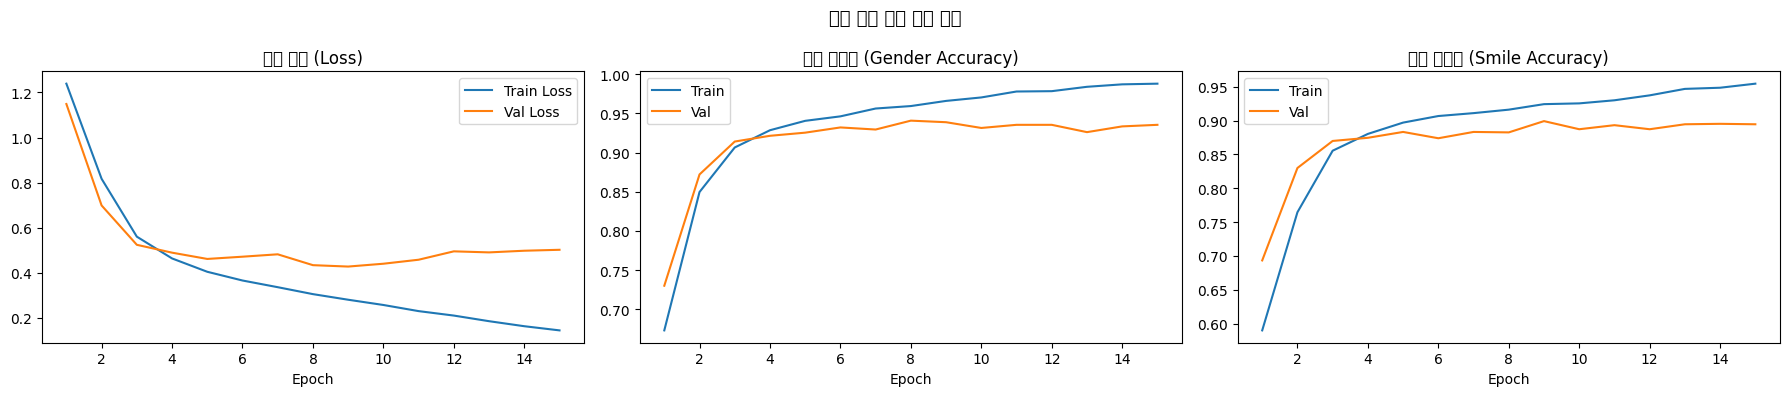

In [21]:
# 멀티 출력 모델 학습 곡선
epochs_range = range(1, len(multi_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs_range, multi_history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, multi_history['val_loss'],   label='Val Loss')
axes[0].set_title('전체 손실 (Loss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_range, multi_history['train_gender_acc'], label='Train')
axes[1].plot(epochs_range, multi_history['val_gender_acc'],   label='Val')
axes[1].set_title('성별 정확도 (Gender Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs_range, multi_history['train_smile_acc'], label='Train')
axes[2].plot(epochs_range, multi_history['val_smile_acc'],   label='Val')
axes[2].set_title('표정 정확도 (Smile Accuracy)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('멀티 출력 모델 학습 곡선', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 멀티 출력 모델 예측 시각화

/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256/3798798379.py:28: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layo

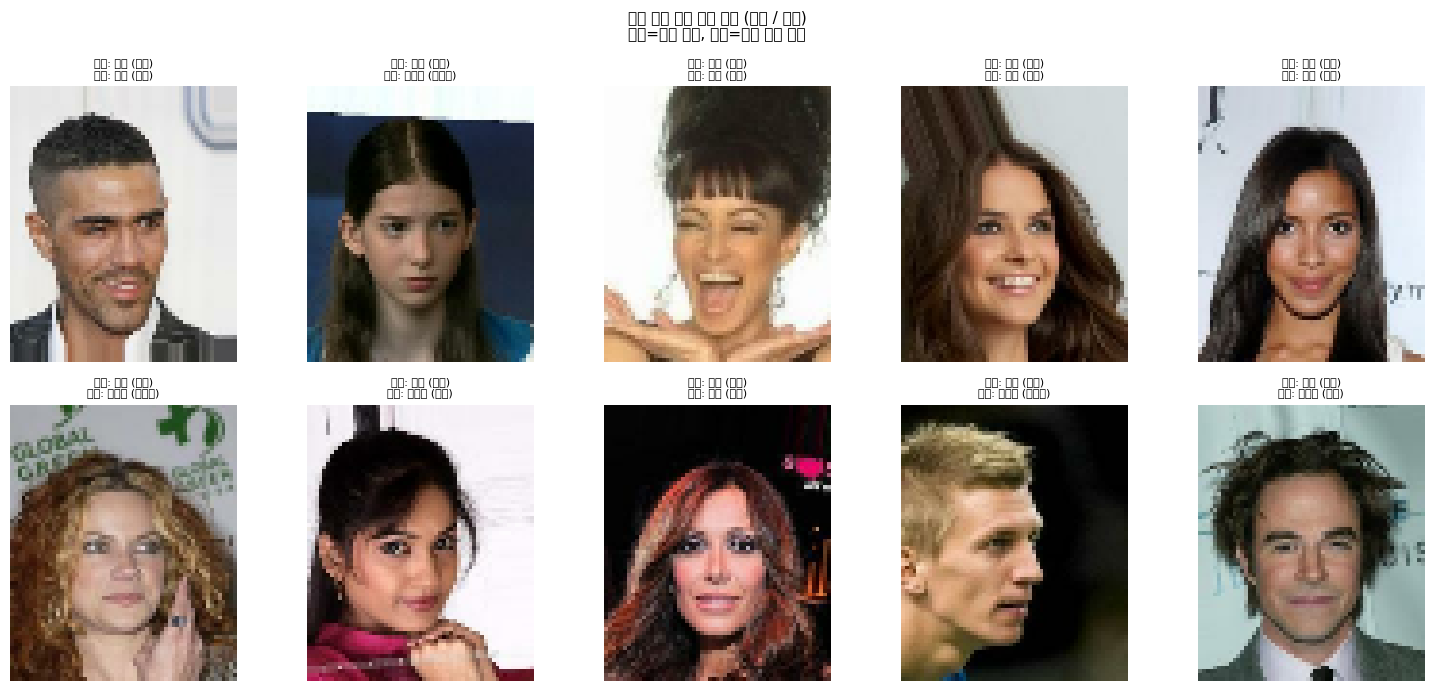

In [22]:
multi_model.eval()

sample_imgs, sample_gender, sample_smile = next(iter(test_loader))
with torch.no_grad():
    g_out, s_out = multi_model(sample_imgs.to(device))
    gender_preds2 = g_out.argmax(dim=1).cpu()
    smile_preds2  = s_out.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].permute(1, 2, 0).numpy()
    ax.imshow(img)

    g_true = gender_map[sample_gender[i].item()]
    g_pred = gender_map[gender_preds2[i].item()]
    s_true = smile_map[sample_smile[i].item()]
    s_pred = smile_map[smile_preds2[i].item()]

    ax.set_title(f'성별: {g_pred} ({g_true})\n표정: {s_pred} ({s_true})', fontsize=8)

    both_correct = (sample_gender[i] == gender_preds2[i]) and (sample_smile[i] == smile_preds2[i])
    for spine in ax.spines.values():
        spine.set_edgecolor('green' if both_correct else 'red')
        spine.set_linewidth(2)
    ax.axis('off')

plt.suptitle('멀티 출력 모델 예측 결과 (예측 / 실제)\n초록=모두 정답, 빨강=하나 이상 오답', fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 6. 서브 모델 추출

멀티 출력 모델에서 성별/표정 개별 예측 함수를 래핑합니다.

In [23]:
class GenderSubModel(nn.Module):
    """멀티 출력 모델에서 성별 헤드만 추출"""
    def __init__(self, multi_output_model):
        super().__init__()
        self.shared      = multi_output_model.shared
        self.gender_head = multi_output_model.gender_head

    def forward(self, x):
        return self.gender_head(self.shared(x))


class SmileSubModel(nn.Module):
    """멀티 출력 모델에서 표정 헤드만 추출"""
    def __init__(self, multi_output_model):
        super().__init__()
        self.shared     = multi_output_model.shared
        self.smile_head = multi_output_model.smile_head

    def forward(self, x):
        return self.smile_head(self.shared(x))


gender_model2 = GenderSubModel(multi_model).to(device).eval()
smile_model2  = SmileSubModel(multi_model).to(device).eval()

# 테스트
with torch.no_grad():
    g_pred = gender_model2(sample_imgs[:3].to(device)).argmax(1)
    s_pred = smile_model2(sample_imgs[:3].to(device)).argmax(1)

print('성별 예측 (서브 모델):', [gender_map[p.item()] for p in g_pred])
print('표정 예측 (서브 모델):', [smile_map[p.item()] for p in s_pred])

성별 예측 (서브 모델): ['남성', '남성', '여성']
표정 예측 (서브 모델): ['미소', '무표정', '미소']


---
## Step 7. 모델 평가 (테스트셋)

In [24]:
def evaluate_model(model, test_loader, mode='multi'):
    """
    테스트셋 평가
    mode: 'gender', 'smile', 'multi'
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()

    results = {}
    g_correct = s_correct = total = 0
    total_loss = 0.0

    with torch.no_grad():
        for imgs, gender, smile in test_loader:
            imgs   = imgs.to(device)
            gender = gender.to(device)
            smile  = smile.to(device)

            if mode == 'gender':
                out = model(imgs)
                loss = criterion(out, gender)
                g_correct += (out.argmax(1) == gender).sum().item()
            elif mode == 'smile':
                out = model(imgs)
                loss = criterion(out, smile)
                s_correct += (out.argmax(1) == smile).sum().item()
            else:  # multi
                g_out, s_out = model(imgs)
                loss = criterion(g_out, gender) + criterion(s_out, smile)
                g_correct += (g_out.argmax(1) == gender).sum().item()
                s_correct += (s_out.argmax(1) == smile).sum().item()

            total_loss += loss.item() * imgs.size(0)
            total += imgs.size(0)

    print(f'테스트 손실: {total_loss/total:.4f}')
    if mode in ('gender', 'multi'):
        print(f'성별 정확도: {g_correct/total:.4f}  ({g_correct}/{total})')
    if mode in ('smile', 'multi'):
        print(f'표정 정확도: {s_correct/total:.4f}  ({s_correct}/{total})')


print('\n[단순 분리 모델]')
print('- 성별 모델 -')
evaluate_model(gender_model.to(device), test_loader, mode='gender')
print('- 표정 모델 -')
evaluate_model(smile_model.to(device),  test_loader, mode='smile')

print('\n[멀티 출력 모델]')
evaluate_model(multi_model, test_loader, mode='multi')


[단순 분리 모델]
- 성별 모델 -
테스트 손실: 0.2563
성별 정확도: 0.9347  (1402/1500)
- 표정 모델 -
테스트 손실: 0.3133
표정 정확도: 0.8880  (1332/1500)

[멀티 출력 모델]
테스트 손실: 0.4723
성별 정확도: 0.9393  (1409/1500)
표정 정확도: 0.8973  (1346/1500)


---
## Step 8. 모델 저장 및 불러오기

In [25]:
# 멀티 출력 모델 저장 (state_dict 방식 권장)
torch.save(multi_model.state_dict(), 'multi_model_celeba.pth')
print('멀티 출력 모델 저장 완료: multi_model_celeba.pth')

# 전체 모델 저장 (불러올 때 클래스 정의 필요)
torch.save(multi_model, 'multi_model_celeba_full.pt')
print('전체 모델 저장 완료: multi_model_celeba_full.pt')

멀티 출력 모델 저장 완료: multi_model_celeba.pth
전체 모델 저장 완료: multi_model_celeba_full.pt


In [26]:
# state_dict 방식으로 불러오기
loaded_model = MultiOutputModel()
loaded_model.load_state_dict(torch.load('multi_model_celeba.pth', map_location=device))
loaded_model = loaded_model.to(device).eval()
print('모델 불러오기 완료!')

# 불러온 모델로 검증
print('\n[불러온 모델 평가]')
evaluate_model(loaded_model, test_loader, mode='multi')

모델 불러오기 완료!

[불러온 모델 평가]
테스트 손실: 0.4723
성별 정확도: 0.9393  (1409/1500)
표정 정확도: 0.8973  (1346/1500)


---
## 정리

| 항목 | TensorFlow/Keras | PyTorch |
|---|---|---|
| 모델 정의 | `keras.Sequential` / 함수형 API | `nn.Module` 클래스 |
| 학습 | `model.fit()` | 수동 루프 (forward → loss → backward → step) |
| 데이터 | `tf.data.Dataset` | `Dataset` + `DataLoader` |
| 손실 함수 | `categorical_crossentropy` | `nn.CrossEntropyLoss` |
| 옵티마이저 | `keras.optimizers.Adam` | `optim.Adam` |
| 이미지 형식 | `(N, H, W, C)` | `(N, C, H, W)` |
| 모델 저장 | `.h5` / `.keras` | `.pth` (state_dict) / `.pt` (전체) |

### 핵심 개념
- **멀티 태스크 학습**: 하나의 모델로 여러 태스크를 동시에 학습 → 공유 표현 학습
- **서브 모델 추출**: `nn.Module`의 레이어를 직접 참조하여 부분 모델 구성 가능
- **손실 합산**: `loss = loss_gender + loss_smile` 형태로 두 태스크의 손실을 합산하여 역전파